# Step 1 - Setup And Exploratory Data Analysis(EDA)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#make plots look a bit nicer.

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
#Load the total Customer Churn dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#Display the total numbaers of rows and columns
print("shape of dataset:", df.shape)  

#Dispaly the first five rows and columns
df.head()



shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#Display the information about the columns, data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#display descriptive statistics of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
#check the number of missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
#check the data types of values in the TotalCharges column
df['TotalCharges'].apply(type).value_counts()

<class 'str'>    7043
Name: TotalCharges, dtype: int64

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64


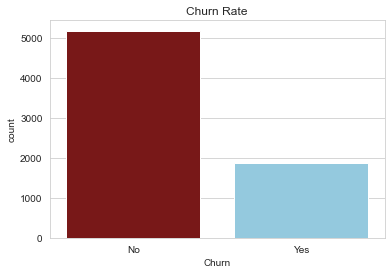

In [8]:
#Calculate the percentage of customers who churned and stayed
churn_rate =df['Churn'].value_counts(normalize=True)*100
print(churn_rate)

#create a count plot to visualize the churn rate
sns.countplot(data=df, x='Churn', palette=['#880808','#87CEEB'])
plt.title("Churn Rate")
plt.show()

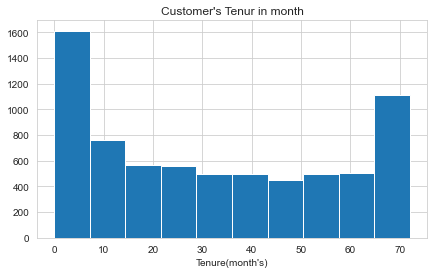

In [9]:
#create a histogram to show customer tenure disturibution
plt.figure(figsize=(7,4))
plt.hist(df['tenure'])
plt.title("Customer's Tenur in month")
plt.xlabel("Tenure(month's)")
plt.show()

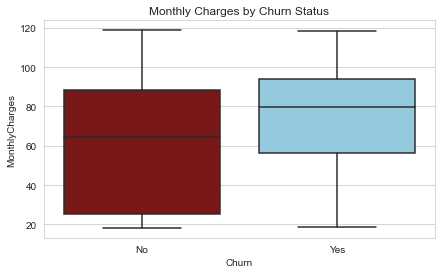

In [10]:
#create a boxplot  to compare monthly charges by churn status
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#880808', '#87CEEB'])
plt.title("Monthly Charges by Churn Status")
plt.show()

#  Step 2 - Data Cleaning & Feature Engineering

In [11]:
#convert Totalcharges column from object srting to numeric
#Invalid values are converted into NaN
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors = "coerce")
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [12]:
#check the number of missing values in each column
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
#filling missing values in Totalcharges column with 0

df['TotalCharges']=df['TotalCharges'].fillna(0)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [14]:
#check again for missing values after filling them
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Encoding

In [15]:
#create a copy of the dataframe and reomve customerId
#customerId is not useful for machine learning prediction
df2=df.drop(columns=['customerID'])
df2

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [16]:
#convert churn values into numerical values 
df2['Churn']= df2['Churn'].map({'Yes':1,'No':0})
df2['Churn'].value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

In [17]:
#select all categorical columns from the dataframe
categ_col = df2.select_dtypes(include='object').columns.tolist()
#convert categorial variables into numerical dummy variables
df2_encoded = pd.get_dummies(df2,columns=categ_col,drop_first=True)
df2_encoded.shape

(7043, 31)

In [18]:
#display the encoded dataframe
df2_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,1,1,1,0,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,0,1,1,1,0,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,0,1,1,0,1,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1


### Feature Scaling

In [19]:
#import standardScale for feature scaling
from sklearn.preprocessing import StandardScaler

#slecting numerical columns that need to be scale
numeric_col =['tenure', 'MonthlyCharges','TotalCharges']

#create a standardScale object
scaler = StandardScaler()

#StandaradScale the selected numerical columns
df2_encoded[numeric_col]= scaler.fit_transform(df2_encoded[numeric_col])

In [20]:
#Display descriptive statistics of the scale numerical columns
df2_encoded[numeric_col].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,5.945991e-17,-8.291599e-17,-2.667184e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01
max,1.613701e+00,1.794352e+00,2.825806e+00


In [21]:
#create X by removing the target variable churn
X =df2_encoded.drop(columns=['Churn'])

#create y containing only the target variable churn
y= df2_encoded['Churn']

print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


### Train-Test Split

In [22]:
#import train_test_split to divide the data into training and tsting sets
from sklearn.model_selection import train_test_split

#Split the dataset into training and testing and testing data
#testing_size=0.20 means 20% data is used for testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42,)

print(X_train.shape[0])
print(X_test.shape[0])

5634
1409


# Step 3 - Model Building

In [23]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using training data
log_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_log = log_model.predict(X_test)

# Display the first few predictions
print(y_pred_log[:10])

[1 0 0 1 0 0 0 0 0 0]


### Decision Tree Classifier

In [24]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
tree_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_tree = tree_model.predict(X_test)

# Display the first few predictions
print(y_pred_tree[:10])

[1 1 0 0 0 0 0 0 1 1]


### Bonus-K-Means Clustering

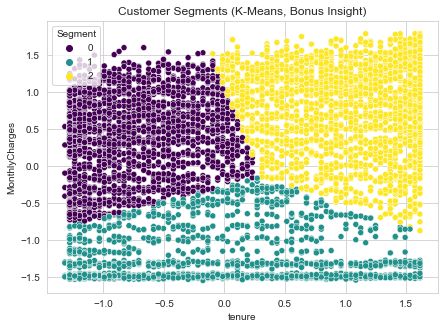

In [36]:
# K-Means is not used for prediction.
# It is used to discover natural customer segments.

from sklearn.cluster import KMeans

# Select tenure and monthly charges for clustering
cluster_features = df2_encoded[["tenure", "MonthlyCharges"]]

# Create K-Means model with 3 customer segments
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Assign each customer to a cluster
df2_encoded["Segment"] = kmeans.fit_predict(cluster_features)

# Create a scatter plot of customer segments
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df2_encoded,
    x="tenure",
    y="MonthlyCharges",
    hue="Segment",
    palette="viridis"
)

# Add title to the plot
plt.title("Customer Segments (K-Means, Bonus Insight)")

# Display the plot
plt.show()

# Step 4 - Evaluation & Warp-Up

In [34]:
# Evaluate both models
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Create a function to evaluate model performance
def evaluate(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print()

# Evaluate Logistic Regression model
evaluate("Logistic Regression", y_test, y_pred_log)

# Evaluate Decision Tree model
evaluate("Decision Tree", y_test, y_pred_tree)

--- Logistic Regression ---
Accuracy: 0.821
Precision: 0.686
Recall: 0.598

--- Decision Tree ---
Accuracy: 0.713
Precision: 0.457
Recall: 0.461



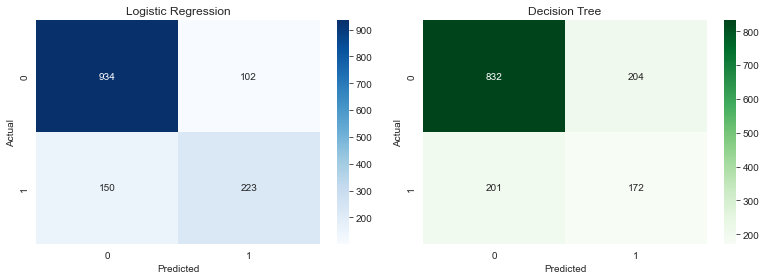

In [35]:
# Plot confusion matrices for both models

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(11,4))

# Create confusion matrix for Logistic Regression
sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

# Add title and labels
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Create confusion matrix for Decision Tree
sns.heatmap(
    confusion_matrix(y_test, y_pred_tree),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

# Add title and labels
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Adjust the layout
plt.tight_layout()

# Display both confusion matrices
plt.show()

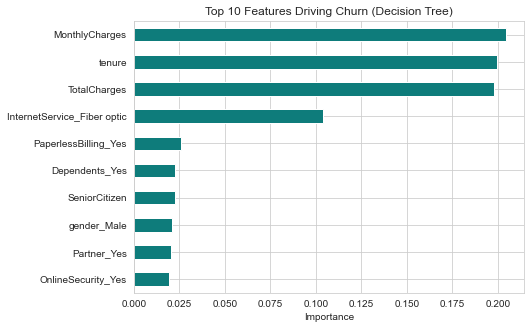

In [27]:
# Feature importance from the Decision Tree — which factors drive churn the most?
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
top_features.sort_values().plot(kind="barh", color="#0E7C7B")
plt.title("Top 10 Features Driving Churn (Decision Tree)")
plt.xlabel("Importance")
plt.show()

# Conclusion

#### This project analyzed the Telco Customer Churn dataset to understand customer churn and build machine learning models for predicting whether a customer is likely to leave the service. The data was cleaned, missing values were handled, categorical features were encoded, and numerical features were scaled.
#### Two classification models, Logistic Regression and Decision Tree Classifier, were trained and evaluated using Accuracy, Precision, Recall, and Confusion Matrix. The analysis also showed which features were most important for churn prediction, with factors such as Monthly Charges, Tenure, and Total Charges playing an important role in the Decision Tree model.
#### As a bonus, K-Means Clustering was used to identify natural customer segments based on tenure and monthly charges. Overall, this project demonstrates how data analysis and machine learning can help a telecom company identify customers at risk of churn and develop targeted retention strategies.